## About Dataset

Lending Club

Lending Club is a peer-to-peer Lending company based in the US. They match people looking to invest money with people looking to borrow money. When investors invest their money through Lending Club, this money is passed onto borrowers, and when borrowers pay their loans back, the capital plus the interest passes on back to the investors. It is a win for everybody as they can get typically lower loan rates and higher investor returns.

The Lending Club dataset contains complete loan data for all loans issued through the 2007-2015, including the current loan status (Current, Late, Fully Paid, etc.) and latest payment information. Features (aka variables) include credit scores, number of finance inquiries, address including zip codes and state, and collections among others. Collections indicates whether the customer has missed one or more payments and the team is trying to recover their money. The file is a matrix of about 890 thousand observations and 75 variables.


Grade | Risk Level | Typical Interest Rate
---|---:|---:
A | Lowest risk | ~6–8%
B | Low risk | ~9–12%
C | Moderate risk | ~13–16%
D | Medium-high risk | ~17–20%
E | High risk | ~21–24%
F | Very high risk | ~25–28%
G | Highest risk | ~29%+

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
pd.options.display.max_rows = None

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Path to dataset files:", path)

100%|██████████| 339M/339M [00:02<00:00, 134MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adarshsng/lending-club-loan-data-csv/versions/1


In [4]:
import os
print(os.listdir(path))

['loan.csv', 'LCDataDictionary.xlsx']


In [5]:
df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = 500000)
df.head()

/tmp/ipykernel_6064/352506140.py:1: DtypeWarning: Columns (112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = 500000)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## EDA

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,500000.0,16006.670650,10131.255236,1000.00,8000.0000,14000.000,22000.0000,4.000000e+04
funded_amnt,500000.0,16006.670650,10131.255236,1000.00,8000.0000,14000.000,22000.0000,4.000000e+04
funded_amnt_inv,500000.0,16003.267372,10131.051724,725.00,8000.0000,14000.000,22000.0000,4.000000e+04
int_rate,500000.0,12.734626,5.151640,5.31,8.4600,11.800,16.0100,3.099000e+01
installment,500000.0,466.270114,286.871203,29.76,254.2700,386.760,628.4900,1.670150e+03
annual_inc,500000.0,80121.894450,89236.750361,0.00,46000.0000,66000.000,96000.0000,9.930475e+06
url,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check missing values

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
id,500000
member_id,500000
url,500000
desc,500000
orig_projected_additional_accrued_interest,499717
hardship_dpd,499668
hardship_amount,499668
hardship_length,499668
hardship_end_date,499668
hardship_status,499668


In [25]:
drop_missing_columns = list(df.columns[df.isnull().sum() > 250000])
drop_missing_columns

['id',
 'member_id',
 'url',
 'desc',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'deferral_term',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_length',
 'hardship_dpd',
 'hardship_loan_status',
 'orig_projected_additional_accrued_interest',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'settlement_amount',

In [27]:
df.drop(columns = drop_missing_columns, inplace=True, axis = 1)

In [30]:
numerical = list(df.dtypes[df.dtypes != 'object'].index)
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

#### Check variable variance

In [31]:
df[numerical].apply(lambda x: x.std()).sort_values()

,0
policy_code,0.000000
num_tl_120dpd_2m,0.002025
num_tl_30dpd,0.008944
acc_now_delinq,0.009591
chargeoff_within_12_mths,0.093132
collections_12_mths_ex_med,0.146510
tax_liens,0.186843
pub_rec_bankruptcies,0.335485
pub_rec,0.387745
num_tl_90g_dpd_24m,0.420170


In [32]:
df['chargeoff_within_12_mths'].value_counts()

,count
chargeoff_within_12_mths,
0,496896
1,2888
2,167
3,27
4,14
6,3
7,2
5,2
9,1


In [33]:
df['policy_code'].value_counts()

,count
policy_code,
1,500000


In [36]:
df['num_tl_120dpd_2m'].value_counts()

,count
num_tl_120dpd_2m,
0.0,487562
1.0,2


In [37]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # tune this

numeric_cols = df.select_dtypes(include='number').columns

selector.fit(df[numeric_cols])

# See which columns are kept
kept = numeric_cols[selector.get_support()]
dropped = numeric_cols[~selector.get_support()]
print("Dropped:", dropped.tolist())

Dropped: ['policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'num_tl_120dpd_2m', 'num_tl_30dpd']


In [38]:
len(dropped)

5

In [42]:
dict = pd.read_excel(os.path.join(path, 'LCDataDictionary.xlsx'))
dict

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...
5,annual_inc_joint,The combined self-reported annual income provi...
6,application_type,Indicates whether the loan is an individual ap...
7,avg_cur_bal,Average current balance of all accounts
8,bc_open_to_buy,Total open to buy on revolving bankcards.
9,bc_util,Ratio of total current balance to high credit/...


In [41]:
for col in categorical:
    print(col, df[col].nunique())
    if df[col].nunique() < 10:
        print(df[col].value_counts())
    print()

term 2
term
36 months    348291
60 months    151709
Name: count, dtype: int64

grade 7
grade
B    142750
A    136102
C    128281
D     69621
E     19223
F      3328
G       695
Name: count, dtype: int64

sub_grade 35

emp_title 130441

emp_length 11

home_ownership 4
home_ownership
MORTGAGE    241585
RENT        197199
OWN          60728
ANY            488
Name: count, dtype: int64

verification_status 3
verification_status
Not Verified       201230
Source Verified    198473
Verified           100297
Name: count, dtype: int64

issue_d 13

loan_status 7
loan_status
Current               439326
Fully Paid             42298
Charged Off             7563
Late (31-120 days)      6565
In Grace Period         2909
Late (16-30 days)       1330
Default                    9
Name: count, dtype: int64

pymnt_plan 2
pymnt_plan
n    499893
y       107
Name: count, dtype: int64

purpose 13

title 12

zip_code 898

addr_state 50

earliest_cr_line 684

initial_list_status 2
initial_list_status
w    4308

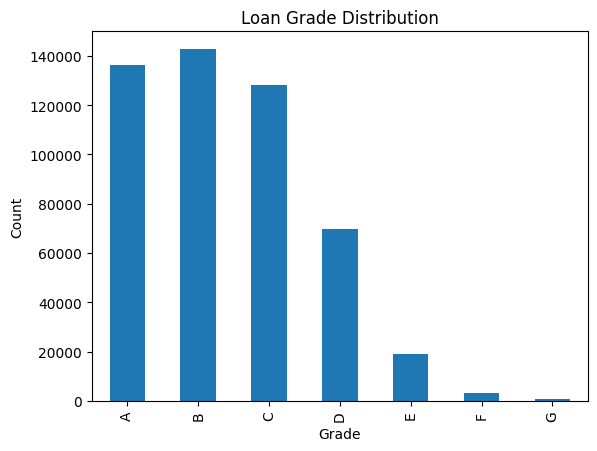

In [49]:
df['grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

ValueError: Could not interpret value `fico_range_low` for `y`. An entry with this name does not appear in `data`.

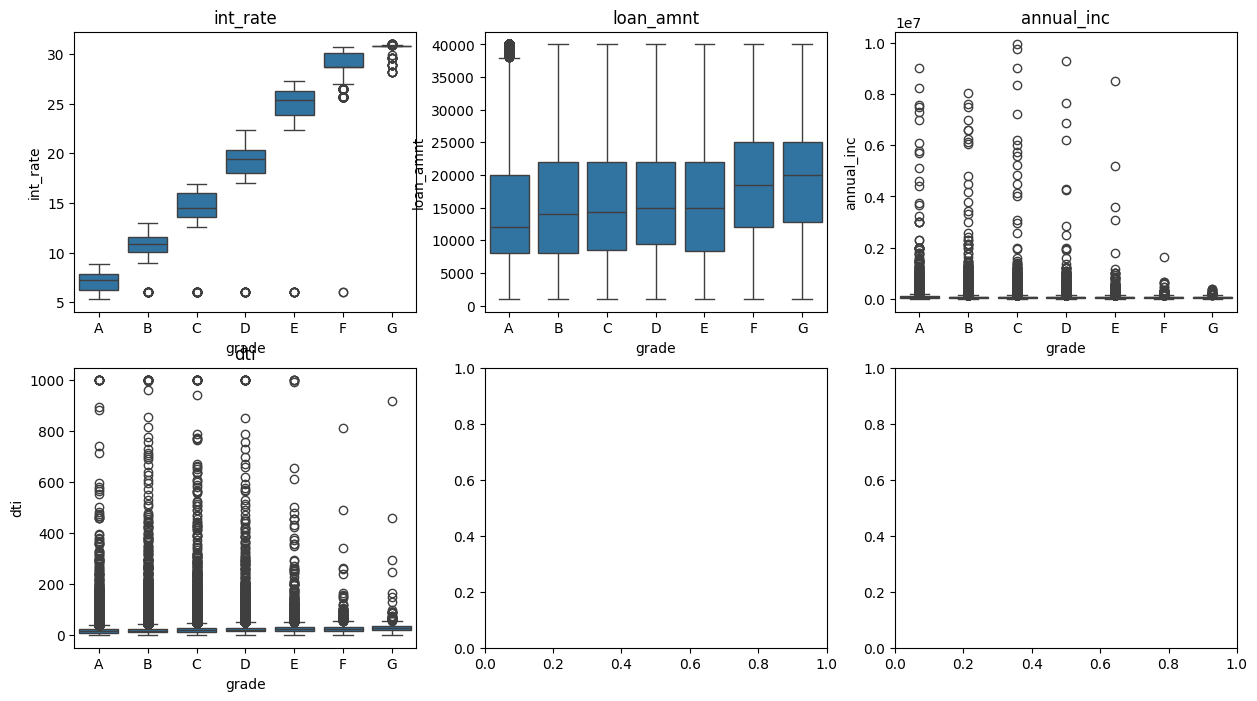

In [50]:
import seaborn as sns

# Box plots for each grade
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['int_rate', 'loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 'installment']

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='grade', y=col, ax=ax, order=sorted(df['grade'].unique()))
    ax.set_title(col)

plt.tight_layout()

### Check correlation

In [51]:
# Encode grade as numeric for correlation
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)

correlations = df.select_dtypes(include='number').corr()['grade_num'].sort_values()
print(correlations.tail(10))  # most positively correlated
print(correlations.head(10))  # most negatively correlated

il_util             0.123488
inq_last_12m        0.123496
revol_util          0.302315
percent_bc_gt_75    0.315585
bc_util             0.321109
all_util            0.322943
total_rec_int       0.408558
int_rate            0.970636
grade_num           1.000000
policy_code              NaN
Name: grade_num, dtype: float64
bc_open_to_buy          -0.320631
total_bc_limit          -0.255908
total_rev_hi_lim        -0.213675
pct_tl_nvr_dlq          -0.128402
tot_hi_cred_lim         -0.116598
mo_sin_old_rev_tl_op    -0.116504
mort_acc                -0.109132
num_bc_tl               -0.100678
mths_since_recent_inq   -0.098741
mo_sin_rcnt_tl          -0.074709
Name: grade_num, dtype: float64
